# Propagation of the error and flags

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS
from src.sanity_checks import *

path_save_fig = DATA_FIGURE / "error_propagation"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# 200 reports
data = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v170626_geo"
data_filtered = "filter_post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v170626_geo"
cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
data = gpd.read_file(os.path.join(DATA_OUT_PROC, data+'.gpkg'), ignore_geometry=True)
data_filtered = gpd.read_file(os.path.join(DATA_OUT_PROC, data_filtered+'.gpkg'), ignore_geometry=True)

In [ ]:
data = format_output(data)
data_filtered_target = format_output(data_filtered)

## Process / harmonize flags

In [11]:
#filter flags
unwanted_flags = [  # flags to filter out (i.e. keep only rows for which these flags are False)
    "flag_remove_cat",
    "flag_value_no_unit",
    "flag_unit_nonstd",
    "flag_response_unit",
    "flag_unknown_subtype",
    "flag_all_hazards_unknown",
    "flag_pop_cntry",
    # "flag_value_not_in_text",
    "flag_remove_unit",
    # "flag_remove_hazard",
]

data_filtered = data[~data[unwanted_flags].any(axis=1)]


In [12]:
results_dict = {
    "pre-filter": data,
    "post-filter": data_filtered
}

# add missing flags
# Flag rows with missing country and location
# df_llm_all_geo["flag_country_location_missing"] = df_llm_all_geo.apply(
#    flag_missing_country_and_location, axis=1
# )
# Flag rows with missing years
for df_name, df in results_dict.items():

    if "flag_years_missing" not in df.columns:
        df["flag_years_missing"] = df.apply(
            flag_years_missing, axis=1
        )

    # Create new flags that combine previous ones
    flags_target = ["flag_partial_unit", "flag_unit_nonstd", "flag_percent"]
    flags_in = [flag for flag in flags_target if flag in df.columns]
    if len(flags_in) != len(flags_target):
        print(
            f"Warning: Not all flags in {flags_target} are present in the DataFrame columns for {df_name}. "
            f"Missing flags: {set(flags_target) - set(flags_in)}"
        )
    df["flag_incorrect_unit"] = (
        df[flags_in]
        .fillna(False)
        .astype(bool)
        .any(axis=1)
    )
    flags_target = [
        "flag_people_unit_normalization",
        "flag_non-SI_unit_standardization",
        "flag_SI_unit_standardization",
        "flag_unit_harmonization",
        "flag_remove_number_unit",
    ]
    flags_in = [
        flag
        for flag in flags_target
        if flag in df.columns

    ]
    if len(flags_in) != len(flags_target):
        print(
            f"Warning: Not all flags in {flags_target} are present in the DataFrame columns for {df_name}. "
            f"Missing flags: {set(flags_target) - set(flags_in)}"
        )
    df["flag_unit_harmonization"] = (
        df[
            flags_in
        ]
        .fillna(False)
        .astype(bool)
        .any(axis=1)
    )
    flags_target = [
        "flag_currency_conversion",
        "flag_unit_conversion",
        "flag_non_currency_unit_conversion",
    ]
    flags_in = [
        flag
        for flag in flags_target
        if flag in df.columns
    ]
    if len(flags_in) != len(flags_target):
        print(
            f"Warning: Not all flags in {flags_target} are present in the DataFrame columns for {df_name}. "
            f"Missing flags: {set(flags_target) - set(flags_in)}"
        )
    df["flag_unit_conversion"] = (
        df[
            flags_in
        ]
        .fillna(False)
        .astype(bool)
        .any(axis=1)
    )

    flags_target = [
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
    ]
    flags_in = [
        flag
        for flag in flags_target
        if flag in df.columns
    ]
    if len(flags_in) != len(flags_target):
        print(
            f"Warning: Not all flags in {flags_target} are present in the DataFrame columns for {df_name}. "
            f"Missing flags: {set(flags_target) - set(flags_in)}"
        )
    df["flag_unit_harmonization_error"] = (
        df[
            flags_in
        ]
        .fillna(False)
        .astype(bool)
        .any(axis=1)
    )
    flags_target = [
        "flag_unit_conversion_error",
        "flag_currency_conversion_error",
        "flag_non_currency_unit_conversion_error",
    ]
    flags_in = [
        flag
        for flag in flags_target
        if flag in df.columns
    ]
    if len(flags_in) != len(flags_target):
        print(
            f"Warning: Not all flags in {flags_target} are present in the DataFrame columns for {df_name}. "
            f"Missing flags: {set(flags_target) - set(flags_in)}"
        )
    df["flag_unit_conversion_error"] = (
        df[
            flags_in
        ]
        .fillna(False)
        .astype(bool)
        .any(axis=1)
    )
    target_drops = [
        "flag_currency_conversion",
        "flag_people_unit_normalization",
        "flag_non-SI_unit_standardization",
        "flag_SI_unit_standardization",
        "flag_remove_number_unit",
        "flag_people_unit_normalization",
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
        "flag_currency_conversion_error",
    ]
    drops_in = [
        flag
        for flag in target_drops
        if flag in df.columns
    ]
    df = df.drop(
        columns=drops_in
    )
    results_dict[df_name] = df

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_66481/556182484.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["flag_incorrect_unit"] = (
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_66481/556182484.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["flag_unit_harmonization"] = (
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_66481/556182484.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [13]:
# check count of error and flag cols for both dataframes
for df_name, df in results_dict.items():

    error_cols = [col for col in df.columns if "error" in col]
    flag_cols = [
        col
        for col in df.columns
        if col.startswith("flag_") or col.startswith("valid_")
    ]

    print(f"DataFrame: {df_name}")
    print(f"Number of error columns: {len(error_cols)}")
    print(f"Number of flag columns: {len(flag_cols)}")

DataFrame: pre-filter
Number of error columns: 6
Number of flag columns: 45
DataFrame: post-filter
Number of error columns: 6
Number of flag columns: 45


In [14]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_missing_startYear',
 'flag_missing_endYear',
 'flag_missing_startMonth',
 'flag_missing_endMonth',
 'flag_missing_startDay',
 'flag_missing_endDay',
 'flag_startYear_after_endYear',
 'flag_inconsistent_year',
 'flag_inconsistent_month',
 'flag_inconsistent_day',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_unit_harmonization',
 'flag_unit_conversion',
 'flag_unit_conversion_error',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_inferred_startYear',
 'flag_failed_startYear_inference',
 'flag_unit_nonstd',
 'flag_value_no_unit',
 'flag_partial_unit',
 'flag_percent',
 'flag_remove_cat',
 'flag_remove_unit',
 'flag_response_unit',
 'flag_remove_hazard',
 'flag_all_hazards_unknown',
 'flag_location_to_country',
 'flag_osm_polygon',
 'flag_no_location',
 'flag_nomin_no_resu

## Normalize flags

In [15]:
# normalize flags to 0 / 1
def normalize_flags(x):
    if x in [0, 0.0, "0", "0.0"]:
        return 0
    elif x in [1, 1.0, "1", "1.0"]:
        return 1
    elif x in [np.nan, "nan", "NaN", None]:
        return np.nan
    else:
        return x

for df_name, df in results_dict.items():

    df[flag_cols] = df[flag_cols].map(normalize_flags)
    results_dict[df_name] = df

## Plots

In [13]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [14]:
## Validation
flags_valid_error = [
    "valid_errors_impactValue",
    "valid_errors_loc",
    "valid_errors_haz",
    "valid_errors_dates",
]
## Value
flags_quanti_value_error = ["flag_value_not_in_text", "flag_pop_cntry"]

## Unit
# flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_partial_unit", "flag_unit_nonstd", "flag_percent"]
flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_unit_incorrect_unit"]

flags_quanti_unit_correction = ["flag_remove_number_unit", "flag_unit_harmonization", "flag_unit_conversion",
                                "flag_SI_unit_standardization", "flag_non-SI_unit_standardization",
                                "flag_people_unit_normalization", "flag_currency_conversion"]

flags_subtypes = ["flag_impactSubtype_reclass", "flag_unknown_subtype", "flag_reclass_subtype_from_unit", "flag_impactSubtype_merged", "flag_response_unit"]
flags_hazard = ["flag_hazards_reclass", "flag_hazards_unknown"]
# flags_coherence = ["flag_pop_cntry"]
flags_remove = [
    "flag_remove_cat",
    "flag_remove_hazard",
    "flag_remove_unit",
    "flag_response_unit",
]

In [19]:
# separate between processing/warning flags and flags that remove rows
flags_by_category = {
    "Subtype": [
        "valid_errors_impactSubtype",
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Value & Unit": [
        "valid_errors_impactValue",
        "flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_SI_unit_standardization",
        "flag_non-SI_unit_standardization",
        "flag_people_unit_normalization",
        "flag_currency_conversion",
        "flag_unit_conversion" "flag_percent",
        "flag_unit_nonstd",
        "flag_value_no_unit",
        "flag_partial_unit",
        "flag_value_not_in_text",
        "flag_unit_conversion_error",
        "flag_pop_cntry",
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
        "flag_unit_harmonization_error",
        "flag_currency_conversion_error",
        "flag_remove_unit",
        "flag_response_unit",
    ],
    "Hazard": [
        "valid_errors_haz",
        "flag_hazards_reclass",
        "flag_hazards_unknown",
        # "flag_remove_hazard",
        "flag_all_hazards_unknown",
    ],
    "Dates": [
        "valid_errors_dates",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_inferred_startYear",
        "flag_failed_startYear_inference",
        "flag_years_missing",
    ],
    "Location": [
        "valid_errors_loc",
        # "flag_geocoding_country",
        # "flag_geocoding_osm",
        "flag_location_to_country",
        "flag_osm_polygon",
        "flag_no_location",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
        "flag_nomin_translate",
        "flag_country_location_missing",
    ],
}


In [ ]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save = False
savename = "validation_flags_warnings_remove"

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Subtype processing": "#bebc9a",
    "Subtype remove": "#bebc9a",
    "Value & Unit processing": "#ca6702",
    "Value & Unit qualitative conversion": "#ca6702",
    "Value & Unit remove": "#ca6702",
    "Hazard processing": "#5c4cac",
    "Hazard remove": "#5c4cac",
    "Dates processing": "#96bb99",
    "Dates remove": "#96bb99",
    "Location processing": "#457b9d",
    "Location remove": "#457b9d",
    "Other": "#999999",
}

domain_color_map = {
    "Subtype": category_palette["Subtype processing"],
    "Value & Unit": category_palette["Value & Unit processing"],
    "Hazard": category_palette["Hazard processing"],
    "Dates": category_palette["Dates processing"],
    "Location": category_palette["Location processing"],
}

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------
source_dict = results_dict
# source_df = results_dict["pre-filter"]
# source_df_filtered = results_dict["post-filter"]

# -----------------------------------------------------------------------------
# Pair warning and removal groups so the row height is shared by domain
# -----------------------------------------------------------------------------

# flag_group_pairs = [
#    ("Subtype", ["Subtype processing"], ["Subtype remove"]),
#    (
#        "Value & Unit",
#        ["Value & Unit processing"],
#        ["Value & Unit qualitative conversion", "Value & Unit remove"],
#    ),
#    ("Hazard", ["Hazard processing"], ["Hazard remove"]),
#    ("Dates", ["Dates processing"], ["Dates remove"]),
#    ("Location", ["Location processing"], ["Location remove"]),
# ]


def ordered_group_flags(flag_dict, group_names, df):
    ordered = []
    flag_to_category = {}
    spans = []

    for group_name in group_names:
        existing_flags = [
            flag for flag in flag_dict.get(group_name, []) if flag in df.columns
        ]

        if not existing_flags:
            continue

        group_counts = (
            df[existing_flags]
            .fillna(False)
            .astype(bool)
            .sum()
            .sort_values(ascending=True)
        )

        start = len(ordered)
        ordered.extend(group_counts.index.tolist())

        for flag in group_counts.index:
            flag_to_category[flag] = group_name

        end = len(ordered) - 1
        spans.append((group_name, start, end))

    return ordered, flag_to_category, spans


panel_data = {
    "Pre-filter flags": [],
    "Post-filter flags": [],
}
group_layout = []
y_start = 0

for domain_name, groups in flags_by_category.items():
    pre_flags_ordered, pre_flags_categories, pre_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["pre-filter"]
    )

    post_flags_ordered, post_flags_categories, post_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["post-filter"]
    )

    group_height = max(len(pre_flags_ordered), len(post_flags_ordered))

    if group_height == 0:
        continue

    group_layout.append((domain_name, y_start, y_start + group_height - 1))

    panel_data["Pre-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": pre_flags_ordered,
            "flag_to_category": pre_flags_categories,
            "spans": pre_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )
    panel_data["Post-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": post_flags_ordered,
            "flag_to_category": post_flags_categories,
            "spans": post_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )

    y_start += group_height

total_y_rows = y_start
all_ordered_flags = [
    flag
    for panel_groups in panel_data.values()
    for group in panel_groups
    for flag in group["ordered_flags"]
]

# -----------------------------------------------------------------------------
# Counts and figure setup
# -----------------------------------------------------------------------------

flag_counts = pd.Series(
    [
        int(source_dict["pre-filter"][flag].fillna(False).astype(bool).sum())
        for flag in all_ordered_flags
    ],
    index=all_ordered_flags,
    dtype=int,
)
add_total_rows = False
total_rows = len(
    source_dict["pre-filter"]
)  # len(source_dict["pre-filter"][source_dict["pre-filter"][all_ordered_flags].any(axis=1)].dropna(how="all"))
label = "total number of rows with at least one flag"
max_x = max(total_rows, flag_counts.max())
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)
fig_height = max(5.5, 0.42 * total_y_rows)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(20, fig_height),
    gridspec_kw={"wspace": 0.65},
)

for ax, (panel_title, panel_groups) in zip(axes, panel_data.items()):
    ax.set_axisbelow(True)

    # -------------------------------------------------------------------------
    # Shared domain shading
    # -------------------------------------------------------------------------

    for domain_name, start, end in group_layout:
        ax.axhspan(
            start - 0.5,
            end + 0.5,
            color="#d9d9d9",
            alpha=0.16,
            zorder=0,
        )

    # -------------------------------------------------------------------------
    # Side-specific group labels, bars, value labels, and error overlays
    # -------------------------------------------------------------------------

    for group in panel_groups:
        y_offset = group["y_offset"]
        ordered_flags = group["ordered_flags"]
        flag_to_category = group["flag_to_category"]
        domain_start = group["y_offset"]
        domain_end = domain_start + group["group_height"] - 1

        domain_color = domain_color_map[group["domain"]]

        group_total = len(
            source_dict["pre-filter"][source_dict["pre-filter"][ordered_flags].any(axis=1)].dropna(how="all")
        )

        ax.axhspan(
            domain_start - 0.5,
            domain_end + 0.5,
            color=domain_color,
            alpha=0.18,
            zorder=0.2,
        )

        ax.text(
            x_max * 0.525,
            domain_start + (domain_end - domain_start) * 0.65,
            f"{group['domain']}\n ({group_total} entries)",
            ha="center",
            va="center",
            fontsize=13,
            color=domain_color,
            alpha=0.95,
            zorder=1.5,
        )

        y_positions = y_offset + np.arange(len(ordered_flags))
        counts = flag_counts.reindex(ordered_flags).fillna(0).astype(int)
        bar_colors = [
            category_palette.get(flag_to_category.get(flag, "Other"), "#666666")
            for flag in ordered_flags
        ]

        ax.barh(
            y_positions,
            counts.values,
            color=bar_colors,
            edgecolor="#2f2f2f",
            linewidth=0.8,
            zorder=2,
        )

        for y_pos, flag_name, flag_count in zip(
            y_positions,
            ordered_flags,
            counts.values,
        ):
            ax.annotate(
                f"{flag_count}",
                xy=(flag_count, y_pos),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=10,
                color="#1f1f1f",
                zorder=4,
            )

            error_col = f"{flag_name}_error"

            if error_col in source_dict["pre-filter"].columns:
                error_count = int(source_dict["pre-filter"][error_col].fillna(False).astype(bool).sum())

                if error_count > 0:
                    ax.hlines(
                        y_pos,
                        0,
                        min(error_count, flag_count),
                        colors="#1f1f1f",
                        linestyles="--",
                        linewidth=2.2,
                        zorder=3,
                    )

    # -------------------------------------------------------------------------
    # Total rows reference line and styling
    # -------------------------------------------------------------------------

    if add_total_rows:
        for _, start, end in group_layout:
            ax.vlines(
                total_rows,
                start - 0.5,
                end + 0.5,
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                zorder=4,
            )

    ax.set_title(panel_title, fontsize=16, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
    ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=13)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("# Entries", fontsize=15)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

axes[0].set_yticks(np.arange(total_y_rows))
axes[0].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Pre-filter flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
axes[1].set_yticks(np.arange(total_y_rows))
axes[1].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Post-filter flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
for ax in axes:
    ax.set_ylim(total_y_rows - 0.5, -0.5)

if add_total_rows:
    axes[1].legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                label=f"{label} ({total_rows})",
            ),
        ],
        fontsize=12,
        loc="lower right",
        frameon=True,
    )

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight"
    )

ValueError: cannot reindex on an axis with duplicate labels

Error in callback <function flush_figures at 0x2de7ee3e0> (for post_execute), with arguments args (),kwargs {}:


In [24]:
flags_by_category

{'Subtype': ['valid_errors_impactSubtype',
  'flag_impactSubtype_reclass',
  'flag_reclass_subtype_from_unit',
  'flag_impactSubtype_merged',
  'flag_unknown_subtype',
  'flag_remove_cat'],
 'Value & Unit': ['valid_errors_impactValue',
  'flag_remove_number_unit',
  'flag_unit_harmonization',
  'flag_unit_conversion',
  'flag_SI_unit_standardization',
  'flag_non-SI_unit_standardization',
  'flag_people_unit_normalization',
  'flag_currency_conversion',
  'flag_unit_conversionflag_percent',
  'flag_unit_nonstd',
  'flag_value_no_unit',
  'flag_partial_unit',
  'flag_value_not_in_text',
  'flag_unit_conversion_error',
  'flag_pop_cntry',
  'flag_remove_number_unit_error',
  'flag_SI_unit_standardization_error',
  'flag_non-SI_unit_standardization_error',
  'flag_unit_harmonization_error',
  'flag_currency_conversion_error',
  'flag_remove_unit',
  'flag_response_unit'],
 'Hazard': ['valid_errors_haz',
  'flag_hazards_reclass',
  'flag_hazards_unknown',
  'flag_all_hazards_unknown'],
 'D

## Legacy plots

In [ ]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [ ]:
## Validation
flags_valid_error = [
    "valid_errors_impactValue",
    "valid_errors_loc",
    "valid_errors_haz",
    "valid_errors_dates",
]
## Value
flags_quanti_value_error = ["flag_value_not_in_text", "flag_pop_cntry"]

## Unit
# flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_partial_unit", "flag_unit_nonstd", "flag_percent"]
flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_unit_incorrect_unit"]

flags_quanti_unit_correction = ["flag_remove_number_unit", "flag_unit_harmonization", "flag_unit_conversion",
                                "flag_SI_unit_standardization", "flag_non-SI_unit_standardization",
                                "flag_people_unit_normalization", "flag_currency_conversion"]

flags_subtypes = ["flag_impactSubtype_reclass", "flag_unknown_subtype", "flag_reclass_subtype_from_unit", "flag_impactSubtype_merged", "flag_response_unit"]
flags_hazard = ["flag_hazards_reclass", "flag_hazards_unknown"]
# flags_coherence = ["flag_pop_cntry"]
flags_remove = [
    "flag_remove_cat",
    "flag_remove_hazard",
    "flag_remove_unit",
    "flag_response_unit",
]

In [ ]:
# separate between processing/warning flags and flags that remove rows
warning_flags = {
    "Subtype processing": [
        "valid_errors_impactSubtype",
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
    ],
    "Value & Unit processing": [
        "valid_errors_impactValue",
        "flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_SI_unit_standardization",
        "flag_non-SI_unit_standardization",
        "flag_people_unit_normalization",
        "flag_currency_conversion",
        "flag_unit_conversion"
        "flag_percent",
        "flag_unit_nonstd",
    ],
    "Hazard processing": [
        "valid_errors_haz",
        "flag_hazards_reclass",
        "flag_hazards_unknown",
        # "flag_remove_hazard",
    ],
    "Dates processing": [
        "valid_errors_dates",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_inferred_startYear",
        "flag_failed_startYear_inference",
    ],
    "Location processing": [
        "valid_errors_loc",
        # "flag_geocoding_country",
        # "flag_geocoding_osm",
        "flag_location_to_country",
        "flag_osm_polygon",
        "flag_no_location",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
        "flag_nomin_translate",
    ],
}

remove_flags = {
    "Subtype remove": [
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Value & Unit qualitative conversion": [
        "flag_value_no_unit",
        "flag_partial_unit",
    ],
    "Value & Unit remove": [
        "flag_value_not_in_text",
        "flag_unit_conversion_error",
        "flag_pop_cntry",
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
        "flag_unit_harmonization_error",
        "flag_currency_conversion_error",
        "flag_remove_unit",
        "flag_response_unit",
    ],
    "Hazard remove": [
        "flag_all_hazards_unknown",
    ],
    "Dates remove": [
        "flag_years_missing",
    ],
    "Location remove": [
        "flag_country_location_missing",
    ],
}

all_flags = {
    "Subtype processing": warning_flags["Subtype processing"],
    "Subtype remove": remove_flags["Subtype remove"],
    "Value & Unit processing": warning_flags["Value & Unit processing"],
    "Value & Unit qualitative conversion": remove_flags["Value & Unit qualitative conversion"],
    "Value & Unit remove": remove_flags["Value & Unit remove"],
    "Hazard processing": warning_flags["Hazard processing"],
    "Hazard remove": remove_flags["Hazard remove"],
    "Dates processing": warning_flags["Dates processing"],
    "Dates remove": remove_flags["Dates remove"],
    "Location processing": warning_flags["Location processing"],
    "Location remove": remove_flags["Location remove"],
}


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_66481/2670935758.py:352: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


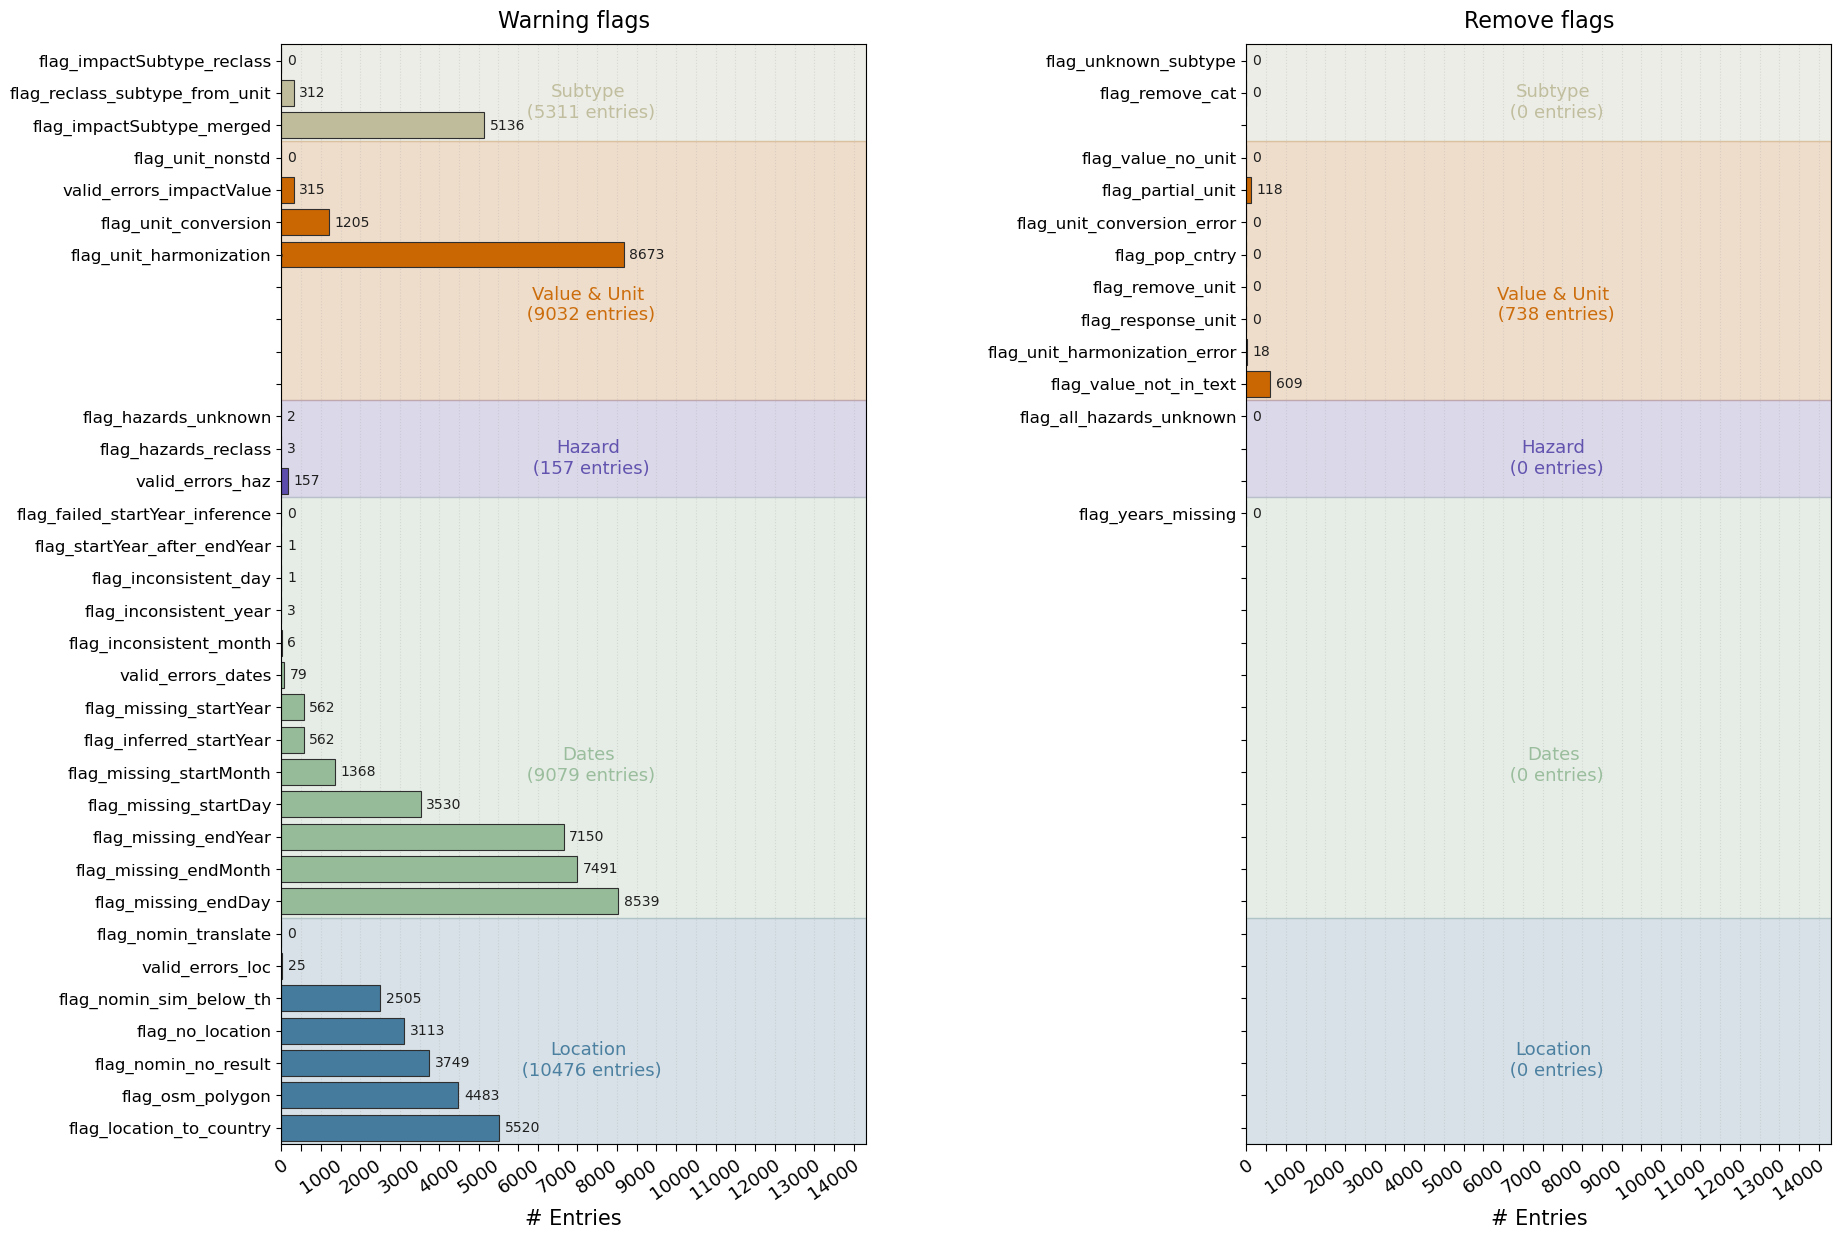

In [ ]:



from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save = False
savename = "validation_flags_warnings_remove"

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Subtype processing": "#bebc9a",
    "Subtype remove": "#bebc9a",
    "Value & Unit processing": "#ca6702",
    "Value & Unit qualitative conversion": "#ca6702",
    "Value & Unit remove": "#ca6702",
    "Hazard processing": "#5c4cac",
    "Hazard remove": "#5c4cac",
    "Dates processing": "#96bb99",
    "Dates remove": "#96bb99",
    "Location processing": "#457b9d",
    "Location remove": "#457b9d",
    "Other": "#999999",
}

domain_color_map = {
    "Subtype": category_palette["Subtype processing"],
    "Value & Unit": category_palette["Value & Unit processing"],
    "Hazard": category_palette["Hazard processing"],
    "Dates": category_palette["Dates processing"],
    "Location": category_palette["Location processing"],
}

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------

source_df = df

# -----------------------------------------------------------------------------
# Pair warning and removal groups so the row height is shared by domain
# -----------------------------------------------------------------------------

flag_group_pairs = [
    ("Subtype", ["Subtype processing"], ["Subtype remove"]),
    (
        "Value & Unit",
        ["Value & Unit processing"],
        ["Value & Unit qualitative conversion", "Value & Unit remove"],
    ),
    ("Hazard", ["Hazard processing"], ["Hazard remove"]),
    ("Dates", ["Dates processing"], ["Dates remove"]),
    ("Location", ["Location processing"], ["Location remove"]),
]


def ordered_group_flags(flag_dict, group_names):
    ordered = []
    flag_to_category = {}
    spans = []

    for group_name in group_names:
        existing_flags = [
            flag for flag in flag_dict.get(group_name, []) if flag in source_df.columns
        ]

        if not existing_flags:
            continue

        group_counts = (
            source_df[existing_flags]
            .fillna(False)
            .astype(bool)
            .sum()
            .sort_values(ascending=True)
        )

        start = len(ordered)
        ordered.extend(group_counts.index.tolist())

        for flag in group_counts.index:
            flag_to_category[flag] = group_name

        end = len(ordered) - 1
        spans.append((group_name, start, end))

    return ordered, flag_to_category, spans


panel_data = {
    "Warning flags": [],
    "Remove flags": [],
}
group_layout = []
y_start = 0

for domain_name, warning_groups, remove_groups in flag_group_pairs:
    warning_ordered, warning_categories, warning_spans = ordered_group_flags(
        warning_flags,
        warning_groups,
    )
    remove_ordered, remove_categories, remove_spans = ordered_group_flags(
        remove_flags,
        remove_groups,
    )

    group_height = max(len(warning_ordered), len(remove_ordered))

    if group_height == 0:
        continue

    group_layout.append((domain_name, y_start, y_start + group_height - 1))

    panel_data["Warning flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": warning_ordered,
            "flag_to_category": warning_categories,
            "spans": warning_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )
    panel_data["Remove flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": remove_ordered,
            "flag_to_category": remove_categories,
            "spans": remove_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )

    y_start += group_height

total_y_rows = y_start
all_ordered_flags = [
    flag
    for panel_groups in panel_data.values()
    for group in panel_groups
    for flag in group["ordered_flags"]
]

# -----------------------------------------------------------------------------
# Counts and figure setup
# -----------------------------------------------------------------------------

flag_counts = pd.Series(
    [int(source_df[flag].fillna(False).astype(bool).sum()) for flag in all_ordered_flags],
    index=all_ordered_flags,
    dtype=int,
)
add_total_rows = False
total_rows = len(
    source_df
)  # len(source_df[source_df[all_ordered_flags].any(axis=1)].dropna(how="all"))
label = "total number of rows with at least one flag"
max_x = max(total_rows, flag_counts.max())
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)
fig_height = max(5.5, 0.42 * total_y_rows)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(20, fig_height),
    gridspec_kw={"wspace": 0.65},
)

for ax, (panel_title, panel_groups) in zip(axes, panel_data.items()):
    ax.set_axisbelow(True)

    # -------------------------------------------------------------------------
    # Shared domain shading
    # -------------------------------------------------------------------------

    for domain_name, start, end in group_layout:
        ax.axhspan(
            start - 0.5,
            end + 0.5,
            color="#d9d9d9",
            alpha=0.16,
            zorder=0,
        )

    # -------------------------------------------------------------------------
    # Side-specific group labels, bars, value labels, and error overlays
    # -------------------------------------------------------------------------

    for group in panel_groups:
        y_offset = group["y_offset"]
        ordered_flags = group["ordered_flags"]
        flag_to_category = group["flag_to_category"]
        domain_start = group["y_offset"]
        domain_end = domain_start + group["group_height"] - 1

        domain_color = domain_color_map[group["domain"]]

        group_total = len(
            source_df[source_df[ordered_flags].any(axis=1)].dropna(how="all")
        )

        ax.axhspan(
            domain_start - 0.5,
            domain_end + 0.5,
            color=domain_color,
            alpha=0.18,
            zorder=0.2,
        )

        ax.text(
            x_max * 0.525,
            domain_start + (domain_end - domain_start) *0.65,
            f"{group['domain']}\n ({group_total} entries)",
            ha="center",
            va="center",
            fontsize=13,
            color=domain_color,
            alpha=0.95,
            zorder=1.5,
        )

        y_positions = y_offset + np.arange(len(ordered_flags))
        counts = flag_counts.reindex(ordered_flags).fillna(0).astype(int)
        bar_colors = [
            category_palette.get(flag_to_category.get(flag, "Other"), "#666666")
            for flag in ordered_flags
        ]

        ax.barh(
            y_positions,
            counts.values,
            color=bar_colors,
            edgecolor="#2f2f2f",
            linewidth=0.8,
            zorder=2,
        )

        for y_pos, flag_name, flag_count in zip(
            y_positions,
            ordered_flags,
            counts.values,
        ):
            ax.annotate(
                f"{flag_count}",
                xy=(flag_count, y_pos),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=10,
                color="#1f1f1f",
                zorder=4,
            )

            error_col = f"{flag_name}_error"

            if error_col in source_df.columns:
                error_count = int(source_df[error_col].fillna(False).astype(bool).sum())

                if error_count > 0:
                    ax.hlines(
                        y_pos,
                        0,
                        min(error_count, flag_count),
                        colors="#1f1f1f",
                        linestyles="--",
                        linewidth=2.2,
                        zorder=3,
                    )

    # -------------------------------------------------------------------------
    # Total rows reference line and styling
    # -------------------------------------------------------------------------

    if add_total_rows:
        for _, start, end in group_layout:
            ax.vlines(
                total_rows,
                start - 0.5,
                end + 0.5,
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                zorder=4,
            )

    ax.set_title(panel_title, fontsize=16, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
    ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=13)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("# Entries", fontsize=15)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

axes[0].set_yticks(np.arange(total_y_rows))
axes[0].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Warning flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
axes[1].set_yticks(np.arange(total_y_rows))
axes[1].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Remove flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
for ax in axes:
    ax.set_ylim(total_y_rows - 0.5, -0.5)

if add_total_rows:
    axes[1].legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                label=f"{label} ({total_rows})",
            ),
        ],
        fontsize=12,
        loc="lower right",
        frameon=True,
    )

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight")

In [18]:
flag_counts

flag_impactSubtype_reclass            25
flag_reclass_subtype_from_unit       314
flag_impactSubtype_merged           5786
valid_errors_impactValue             415
flag_unit_nonstd                    1322
flag_unit_conversion                2642
flag_unit_harmonization            10865
flag_hazards_unknown                   4
flag_hazards_reclass                   5
valid_errors_haz                     212
flag_inconsistent_day                  1
flag_startYear_after_endYear           3
flag_inconsistent_year                 3
flag_failed_startYear_inference        7
flag_inconsistent_month               13
valid_errors_dates                    83
flag_inferred_startYear              919
flag_missing_startYear               926
flag_missing_startMonth             2073
flag_missing_startDay               4742
flag_missing_endYear                8820
flag_missing_endMonth               9313
flag_missing_endDay                10576
flag_nomin_translate                   0
valid_errors_loc

In [19]:
domain_start

27

In [20]:
domain_end

33

In [ ]:
# The quanti rows are the rows with a value in the impactValue column
df_llm_all_geo_quanti = df_llm_all_geo[df_llm_all_geo["impactValue"].notna()].copy()


valid_errors_loc 33
valid_errors_dates 83
valid_errors_haz 212
valid_errors_impactValue 415
flag_pop_cntry 7
flag_value_not_in_text 834
flag_value_no_unit 0
flag_unit_conversion 2582
flag_unit_harmonization 9915
flag_impactSubtype_reclass 25
flag_unknown_subtype 32
flag_response_unit 120
flag_reclass_subtype_from_unit 314
flag_impactSubtype_merged 5786
flag_hazards_unknown 4
flag_hazards_reclass 5
flag_remove_unit 105
flag_response_unit 120
flag_remove_hazard 217
flag_remove_cat 3334
flag_unit_conversion_error 51
flag_unit_harmonization_error 73


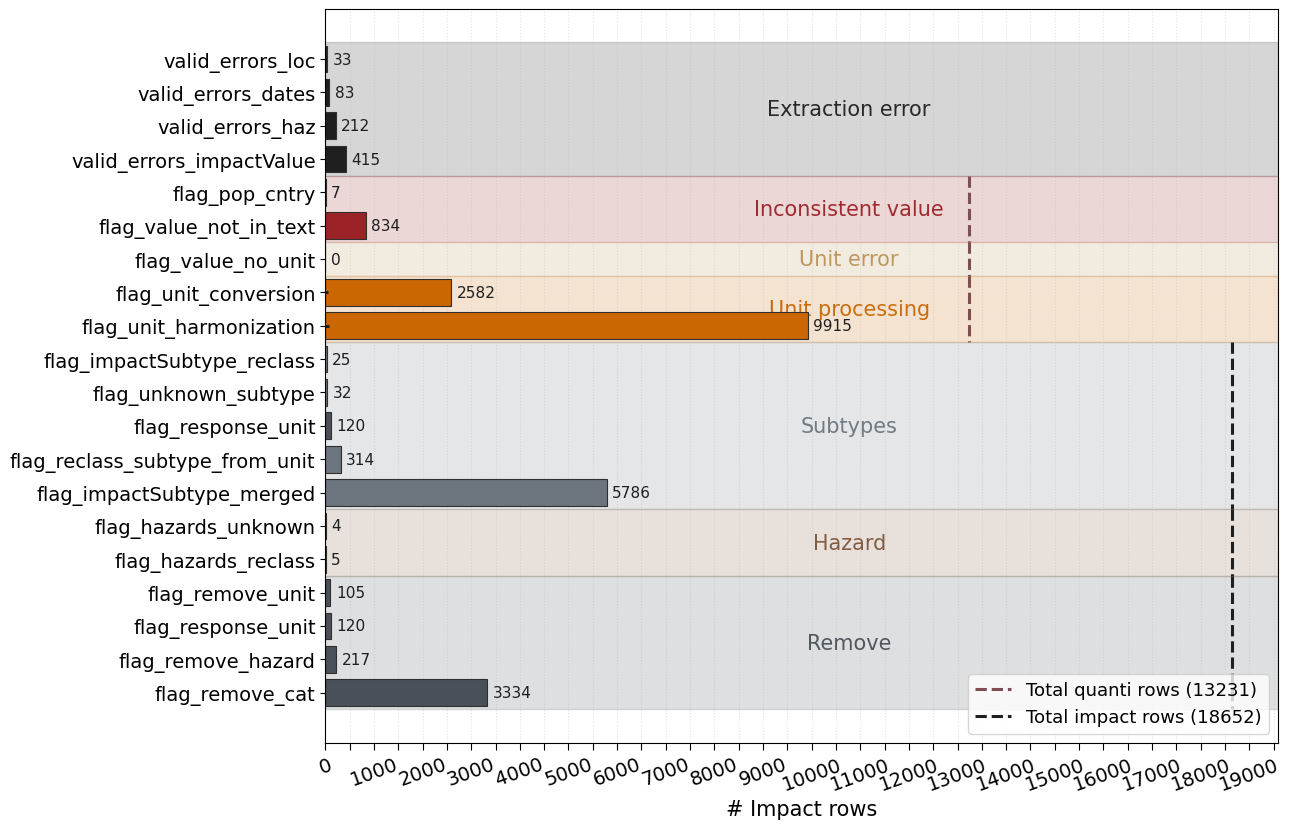

In [22]:
flag_groups = [
    ("Extraction error", flags_valid_error),
    ("Inconsistent value", flags_quanti_value_error),
    ("Unit error", flags_quanti_unit),
    ("Unit processing", flags_quanti_unit_correction),
    ("Subtypes", flags_subtypes),
    ("Hazard", flags_hazard),
    #("Coherence", flags_coherence),
    ("Remove", flags_remove),
]
category_palette = {
    "Extraction error": "#1f1f1f",
    "Inconsistent value": "#9b2226",
    "Unit error": "#bb9457",
    "Unit processing": "#ca6702",
    #"Remove quanti": "#7d4f50",
    "Subtypes": "#6c757d",
    "Hazard": "#7f5539",
    #"Coherence": "#adb5bd",
    "Remove": "#495057",
}

quanti_groups = {"Inconsistent value", "Unit error", "Unit processing", "Remove quanti"}
other_groups = {"Subtypes", "Hazard", "Coherence", "Remove"}

# Keep the group order used in the notebook and add any remaining flags at the end.
known_flags = {flag for _, group in flag_groups for flag in group}
base_flags = [flag for flag in flag_cols ]#if not flag.endswith("_error")]
remaining_flags = [flag for flag in base_flags if flag not in known_flags]

ordered_flags = []
category_spans = []
flag_to_category = {}
for group_index, (group_name, group_flags) in enumerate(flag_groups):
    existing_flags = [flag for flag in group_flags if flag in base_flags]
    if not existing_flags:
        continue
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    group_counts = (
        source_df[existing_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )
    start = len(ordered_flags)
    ordered_flags.extend(group_counts.index.tolist())
    for flag in group_counts.index.tolist():
        flag_to_category[flag] = group_name
    end = len(ordered_flags) - 1
    category_spans.append((group_name, start, end, group_index))

flag_counts = []
for flag in ordered_flags:
    group_name = flag_to_category.get(flag, "")
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    print(flag, source_df[flag].fillna(False).astype(bool).sum())
    flag_counts.append(int(source_df[flag].fillna(False).astype(bool).sum()))
flag_counts = pd.Series(flag_counts, index=ordered_flags, dtype=int)

bar_colors = [category_palette.get(flag_to_category.get(flag, ""), "#666666") for flag in ordered_flags]

total_impact_rows = len(df_llm_all_geo)
total_quanti_rows = len(df_llm_all_geo_quanti)
max_x = int(max(total_impact_rows, total_quanti_rows, flag_counts.max())) if len(flag_counts) else max(total_impact_rows, total_quanti_rows)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig_height = max(5.5, 0.42 * len(ordered_flags))
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.set_axisbelow(True)

for group_name, start, end, _ in category_spans:
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=category_palette.get(group_name, "#d9d9d9"),
        alpha=0.18,
        zorder=0,
    )

label_x = x_max * 0.55
for group_name, start, end, _ in category_spans:
    ax.text(
        label_x,
        (start + end) / 2,
        group_name,
        ha="center",
        va="center",
        fontsize=15,
        color=category_palette.get(group_name, "#1f1f1f"),
        alpha=0.95,
        zorder=1.5,
    )

y_positions = np.arange(len(ordered_flags))
ax.barh(y_positions, flag_counts.values, color=bar_colors, edgecolor="#2f2f2f", linewidth=0.8, zorder=2)

for y_pos, flag_name, flag_count in zip(y_positions, ordered_flags, flag_counts.values):
    ax.annotate(
        f"{int(flag_count)}",
        xy=(flag_count, y_pos),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=11,
        color="#1f1f1f",
        zorder=4,
    )
    error_col = f"{flag_name}_error"
    if error_col in df_llm_all_geo.columns:
        source_df = df_llm_all_geo_quanti if flag_to_category.get(flag_name, "") in quanti_groups else df_llm_all_geo
        error_count = int(source_df[error_col].fillna(False).astype(bool).sum())
        print(error_col, error_count)
        if error_count > 0:
            ax.hlines(
                y_pos,
                0,
                min(error_count, flag_count),
                colors="#1f1f1f",
                linestyles="--",
                linewidth=2.2,
                zorder=3,
            )

for group_name, start, end, _ in category_spans:
    if group_name in quanti_groups:
        ax.vlines(
            total_quanti_rows,
            start - 0.5,
            end + 0.5,
            color="#7d4f50",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )
    elif group_name in other_groups:
        ax.vlines(
            total_impact_rows,
            start - 0.5,
            end + 0.5,
            color="#1f1f1f",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{tick}" if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=20, labelsize=14)
ax.set_xlim(0, x_max)
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_flags, fontsize=14)
ax.set_xlabel("# Impact rows", fontsize=15)
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

ax.legend(handles=[
    Line2D([0], [0], color="#7d4f50", linestyle="--", linewidth=2.2, label=f"Total quanti rows ({total_quanti_rows})"),
    Line2D([0], [0], color="#1f1f1f", linestyle="--", linewidth=2.2, label=f"Total impact rows ({total_impact_rows})"),
], fontsize=13, loc="lower right", frameon=True)

plt.tight_layout()
#fig.savefig(path_save_fig / "flags.png", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# Geocoding 

In [23]:
nominatim_output = pd.read_pickle(DATA_OUT_PROC / "nominatim_output_220526.pkl")
geocoding_unique = gpd.read_file(DATA_OUT_PROC / "geocode_unique_220526.gpkg")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lseverino/Documents/PhD/Projects/Como/Data_backup/results_proc/nominatim_output_220526.pkl'

In [ ]:
geocoding_unique.location.nunique()

8898

In [ ]:
# Aggregate per unique location so repeated split rows count as one location.
existing_flag_cols = [flag for flag in flag_cols if flag in geocoding_unique.columns]
grouped_locations = geocoding_unique.groupby("location", dropna=False)

location_summary = grouped_locations.agg(
    finest_level=("finest_level", lambda s: pd.to_numeric(s, errors="coerce").max()),
).reset_index()
for flag in existing_flag_cols:
    location_summary[flag] = grouped_locations[flag].apply(
        lambda s: int(pd.to_numeric(s, errors="coerce").fillna(0).astype(bool).all())
    ).to_numpy()

location_summary["flag_count"] = location_summary[existing_flag_cols].sum(axis=1) if existing_flag_cols else 0
location_summary

,location,finest_level,flag_geocoding_country,flag_geocoding_osm,flag_count
0,'Eua,1.0,0,0,0
1,1 de Diciembre,2.0,0,0,0
2,"1,144 villages",0.0,1,0,1
3,"1,208 villages across 106 districts in 15 prov...",0.0,1,0,1
4,"1,215 barangays",2.0,0,1,1
...,...,...,...,...,...
8893,Đurđevik,2.0,0,1,1
8894,Šabac,2.0,0,0,0
8895,Žitorađa,0.0,1,0,1
8896,Živinice,2.0,0,1,1


In [ ]:
location_summary.finest_level.value_counts().sort_index()

finest_level
0.0    3248
1.0    2439
2.0    3207
Name: count, dtype: int64

In [ ]:
location_summary.groupby("finest_level")["flag_geocoding_country"].sum().sort_index()

finest_level
0.0    3127
1.0       0
2.0       0
Name: flag_geocoding_country, dtype: int64

In [ ]:
location_summary.groupby("finest_level")["flag_geocoding_osm"].sum().sort_index()

finest_level
0.0       0
1.0     448
2.0    1337
Name: flag_geocoding_osm, dtype: int64

In [ ]:
len(location_summary)

8898